## Basic 3D Scatter Plot (Matplotlib)
🔹 Minimal, correct setup

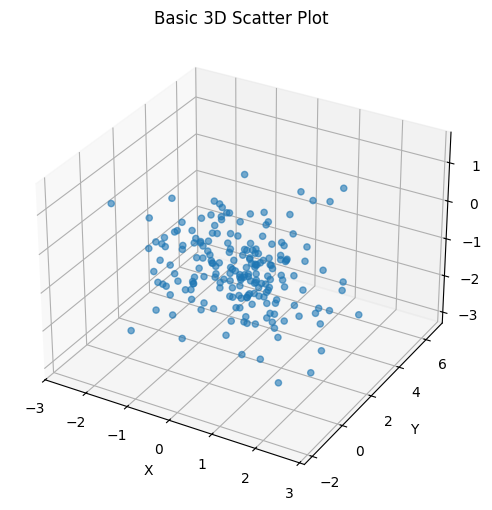

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa

# Sample data
np.random.seed(42)
x = np.random.normal(0, 1, 200)
y = np.random.normal(2, 1.2, 200)
z = np.random.normal(-1, 0.8, 200)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(x, y, z, alpha=0.6)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Basic 3D Scatter Plot")

plt.show()


## 3D Scatter Plot with Color Encoding (4th Dimension)

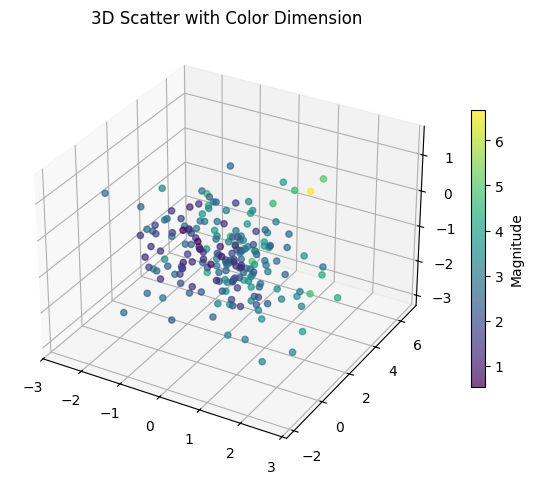

In [2]:
c = np.sqrt(x**2 + y**2 + z**2)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(x, y, z, c=c, alpha=0.7)
plt.colorbar(sc, ax=ax, shrink=0.6, label="Magnitude")

ax.set_title("3D Scatter with Color Dimension")
plt.show()


## 3D Scatter Plot with Size Encoding

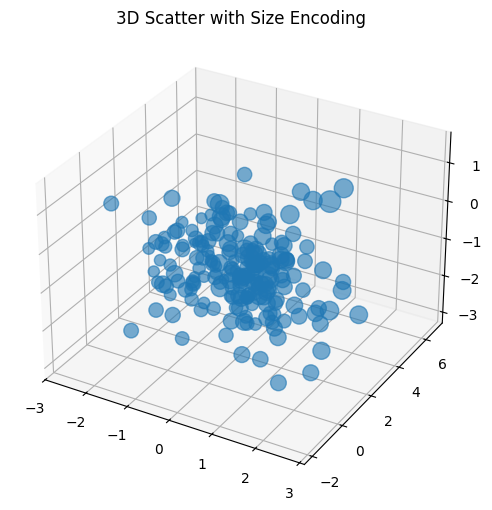

In [3]:
size = 40 + 200 * (c - c.min()) / (c.max() - c.min())

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(x, y, z, s=size, alpha=0.6)
ax.set_title("3D Scatter with Size Encoding")
plt.show()


## 3D Scatter with Categories (Class Labels)

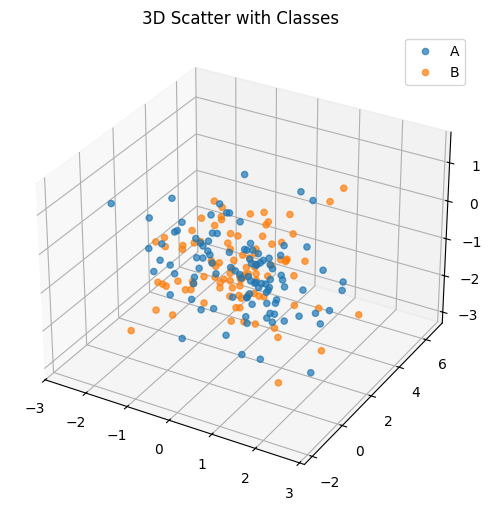

In [4]:
labels = np.random.choice(["A", "B"], 200)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

for lab in np.unique(labels):
    idx = labels == lab
    ax.scatter(
        x[idx], y[idx], z[idx],
        alpha=0.7,
        label=lab
    )

ax.legend()
ax.set_title("3D Scatter with Classes")
plt.show()


## 3D Scatter with Projection Planes

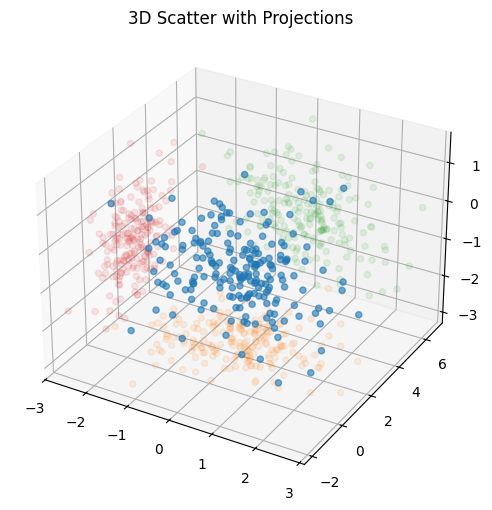

In [5]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(x, y, z, alpha=0.6)

# Projections
ax.scatter(x, y, np.min(z), alpha=0.1)
ax.scatter(x, np.max(y), z, alpha=0.1)
ax.scatter(np.min(x), y, z, alpha=0.1)

ax.set_title("3D Scatter with Projections")
plt.show()


## 3D Scatter for Clusters (KMeans Example)


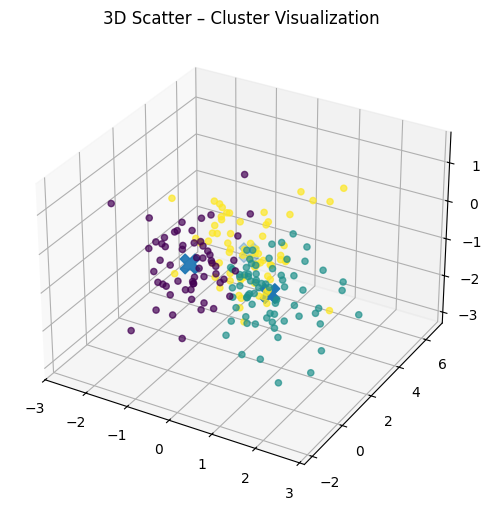

In [6]:
from sklearn.cluster import KMeans

data = np.column_stack([x, y, z])
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(data)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(x, y, z, c=labels, alpha=0.7)
ax.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    kmeans.cluster_centers_[:, 2],
    s=200, marker="X"
)

ax.set_title("3D Scatter – Cluster Visualization")
plt.show()


## Animated 3D Scatter (Rotation Insight)

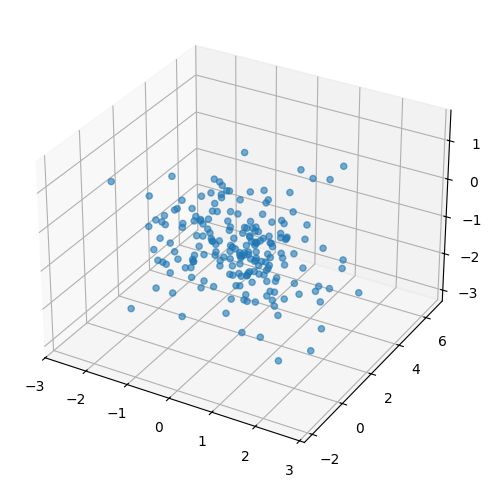

In [7]:
from matplotlib.animation import FuncAnimation

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(x, y, z, alpha=0.6)

def update(angle):
    ax.view_init(30, angle)
    return sc,

ani = FuncAnimation(fig, update, frames=np.arange(0, 360, 2))
plt.show()


## Interactive 3D Scatter (Plotly – Best)
🔹 Highly recommended for exploration

In [8]:
import plotly.express as px
import pandas as pd

df = pd.DataFrame({
    "X": x,
    "Y": y,
    "Z": z,
    "Class": labels
})

fig = px.scatter_3d(
    df,
    x="X",
    y="Y",
    z="Z",
    color="Class",
    opacity=0.7,
    title="Interactive 3D Scatter Plot"
)

fig.show()
